
[k = 2 seqs]
  mean:  -0.00227
  stdev:    0.70478  )theoretical = 0.70711)
  skewness:  0.00320
  kurtosis: -0.58544

[k = 5 seqs]
  mean:   0.00039
  stdev:    0.44518  )theoretical = 0.44721)
  skewness: -0.01345
  kurtosis: -0.25096

[k = 10 seqs]
  mean:   0.00199
  stdev:    0.31778  )theoretical = 0.31623)
  skewness:  0.01391
  kurtosis: -0.20022

[k = 25 seqs]
  mean:   0.00048
  stdev:    0.20315  )theoretical = 0.20000)
  skewness: -0.00771
  kurtosis: -0.04049


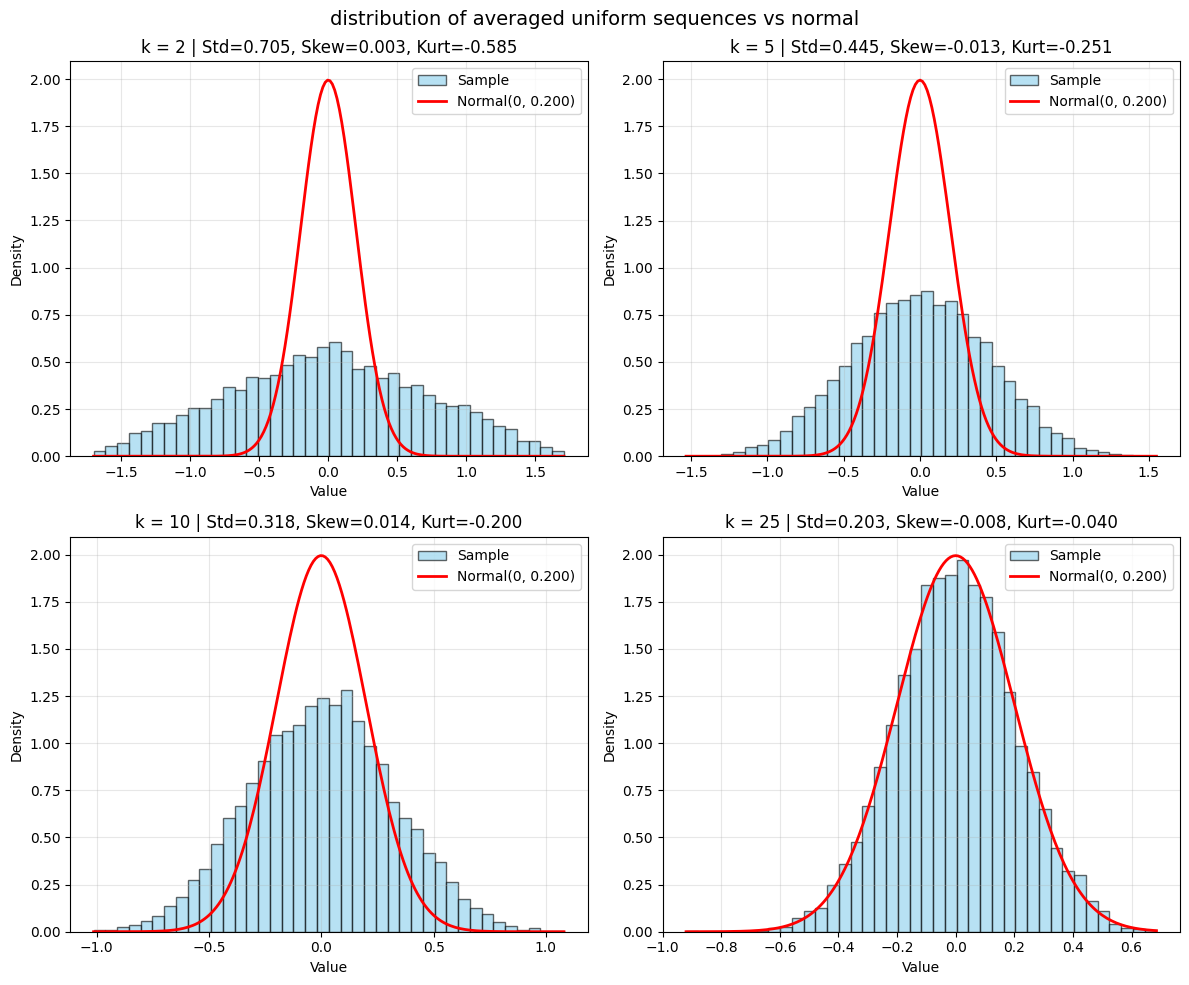

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm, binom, poisson

np.random.seed(42)

# 1
# uniform(0, 1): mean = 1/2, var = 1/12, stdev = 1 / sqrt(12)
# X = (U - 0.5) / sqrt(1/12) = sqrt(12) * (U - 0.5)
# E[X] = 0, var = 1

def standard_uni(size):
    u = np.random.uniform(0, 1, size=size)
    return np.sqrt(12) * (u - 0.5)

N_lnth = 10000
k_vals = [2, 5, 10, 25]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, k in enumerate(k_vals):
    sequences = standard_uni((k, N_lnth))
    avg_seq = np.mean(sequences, axis=0)


    m = np.mean(avg_seq)
    s = np.std(avg_seq, ddof=1)
    sk = skew(avg_seq)
    kt = kurtosis(avg_seq, fisher=True)  # Fisher kurtosis (Normal = 0)

    theo_stdev = 1.0 / np.sqrt(k)

    print(f"\n[k = {k} seqs]")
    print(f"  mean:  {m:8.5f}")
    print(f"  stdev:   {s:8.5f}  )theoretical = {theo_stdev:.5f})")
    print(f"  skewness: {sk:8.5f}")
    print(f"  kurtosis: {kt:8.5f}")

    
    ax = axes[idx]
    count, bins, _ = ax.hist(avg_seq, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample')
    

    x = np.linspace(bins[0], bins[-1], 200)
    ax.plot(x, norm.pdf(x, loc=0, scale=th_std), 'r-', lw=2, label=f'Normal(0, {th_std:.3f})')
    ax.set_title(f"k = {k} | Std={s:.3f}, Skew={sk:.3f}, Kurt={kt:.3f}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("distribution of averaged uniform sequences vs normal", fontsize=14)
plt.tight_layout()
plt.show()



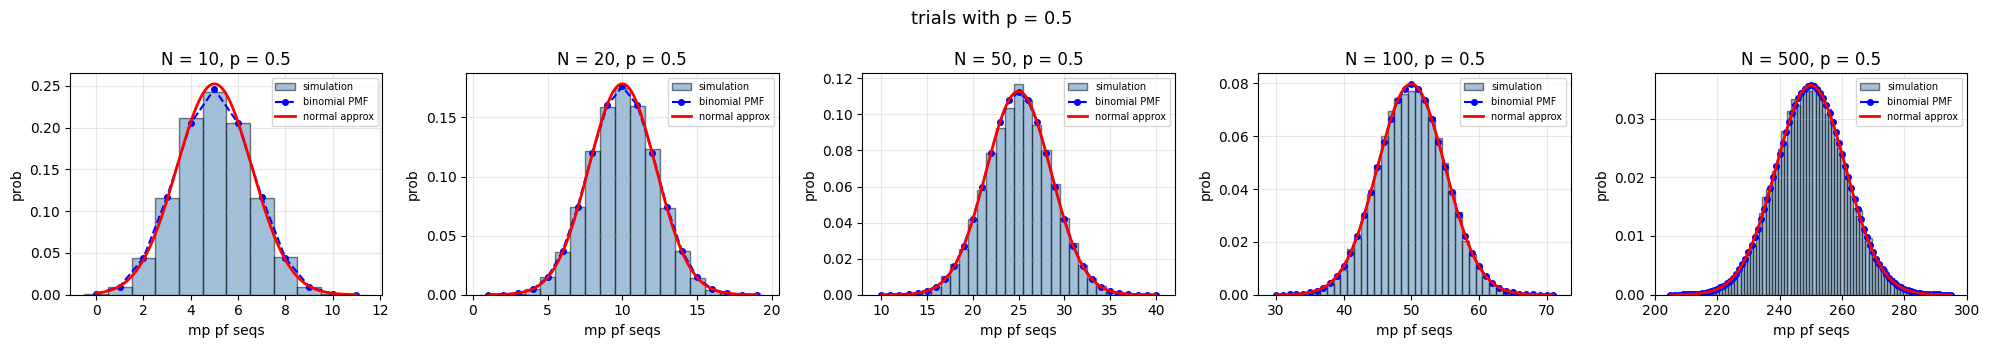

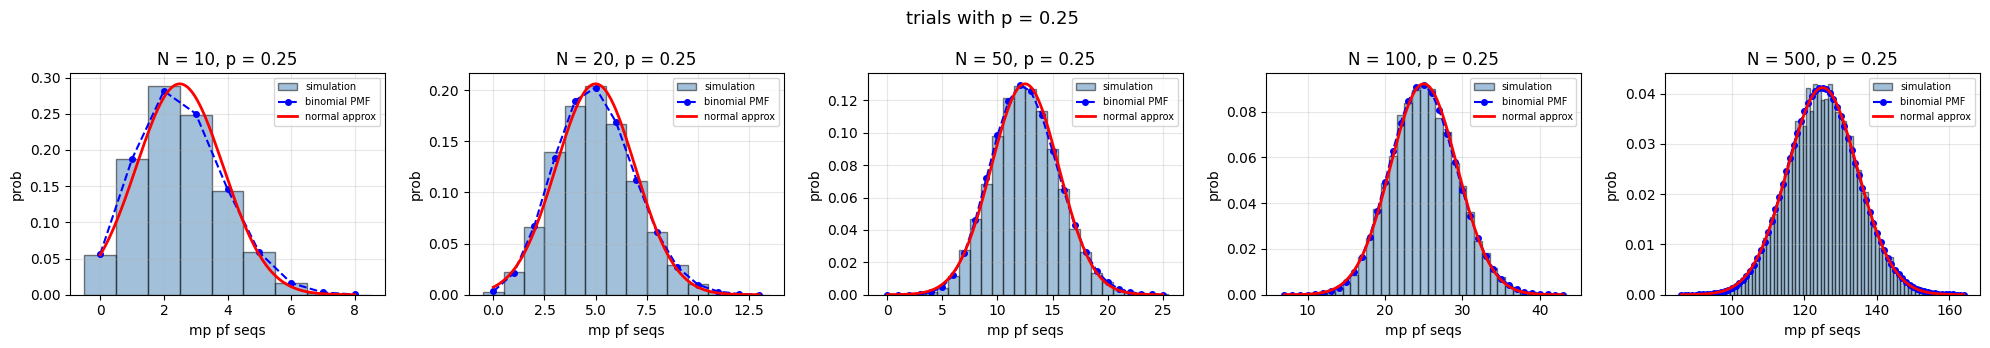

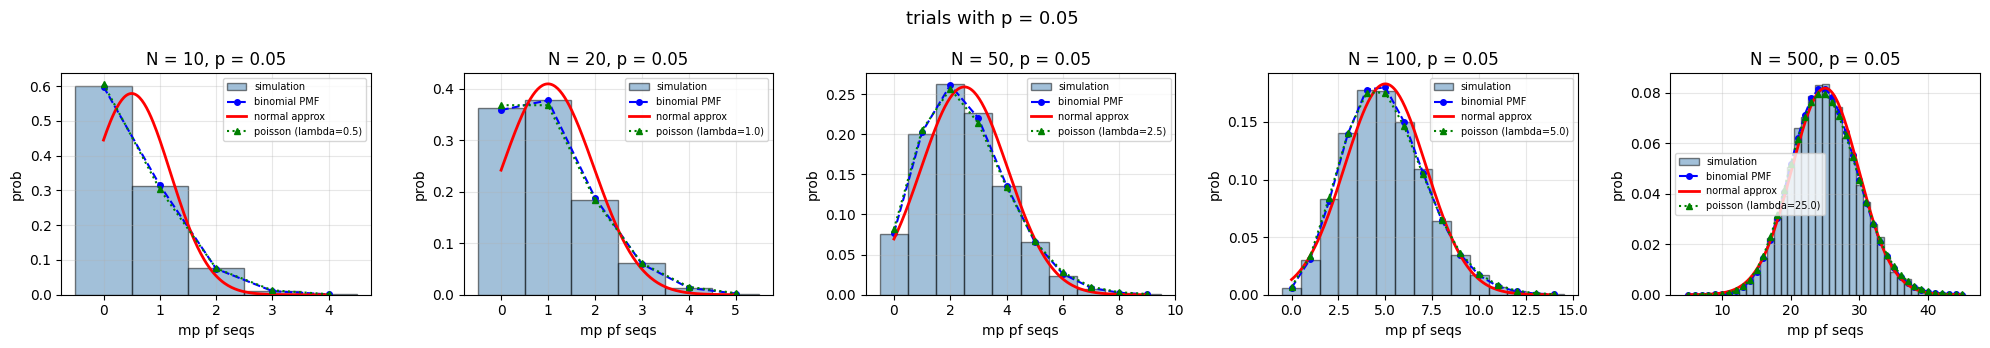

In [8]:

# 2
def binomial(N, p, trials=20000):
    return np.random.binomial(n=N, p=p, size=trials)

def plot_2(p, N_list, pois=False, title_suffix=""):
    fig, axes = plt.subplots(1, len(N_list), figsize=(4 * len(N_list), 3.5))
    if len(N_list) == 1:
        axes = [axes]

    for ax, N in zip(axes, N_list):
        samp = binomial(N, p)
        mu = N * p
        sigma = np.sqrt(N * p * (1 - p))


        k_min = max(0, int(mu - 4 * sigma))
        k_max = int(min(N, mu + 4 * sigma) + 1)
        k_val = np.arange(k_min, k_max + 1)


        bins = np.arange(k_min - 0.5, k_max + 1.5, 1)
        ax.hist(samp, bins=bins, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='simulation')

        # binomial PMF
        ax.plot(k_val, binom.pmf(k_val, N, p), 'bo--', markersize=4, label='binomial PMF')

        # normal approximation
        x_dense = np.linspace(k_min, k_max, 200)
        ax.plot(x_dense, norm.pdf(x_dense, loc=mu, scale=sigma), 'r-', lw=2, label='normal approx')

        # poisson
        if pois:
            ax.plot(k_val, poisson.pmf(k_val, mu), 'g^:', markersize=4, label=f'poisson (lambda={mu:.1f})')

        ax.set_title(f"N = {N}, p = {p}")
        ax.set_xlabel("mp pf seqs")
        ax.set_ylabel("prob")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"trials with p = {p} {title_suffix}", fontsize=13)
    plt.tight_layout()
    plt.show()

# p = 0.5
plot_2(p=0.5, N_list=[10, 20, 50, 100, 500])

# p = 0.25
plot_2(p=0.25, N_list=[10, 20, 50, 100, 500])

# p = 0.05 ()compare poisson)
plot_2(p=0.05, N_list=[10, 20, 50, 100, 500], pois=True)




Nh-Nt: 1,500
max +ve deviation = 2,026
max -ve dev =   -4
zero crossings total:     8
avg stretch between 0s:   17.43 tosses
max stretch between 0s:   82 tosses


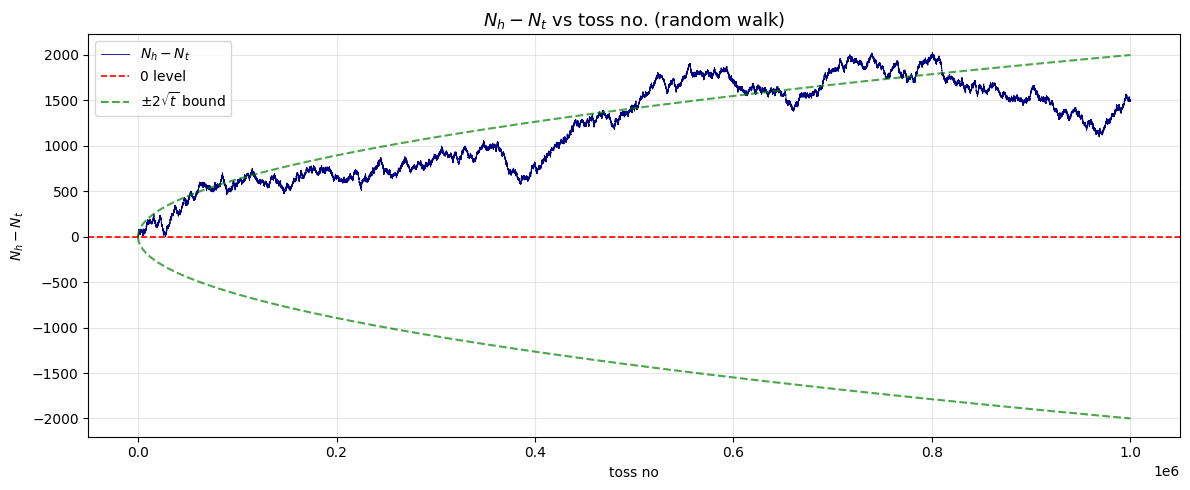

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 3
tosses = 1000000
steps = np.random.choice([1, -1], size=tosses, p=[0.5, 0.5])
# diff is cumulative sum
diff = np.cumsum(steps)

# zero crossing 
zero_crossing = np.where(diff == 0)[0]
num_cross = len(zero_crossing)

if num_cross > 1:
    stretch = np.diff(zero_crossing)
    max_stretch = np.max(stretch)
    mean_stretch = np.mean(stretch)
else:
    max_stretch = 0
    mean_stretch = 0

print(f"Nh-Nt: {diff[-1]:,}")
print(f"max +ve deviation = {np.max(diff):,}")
print(f"max -ve dev =   {np.min(diff):,}")
print(f"zero crossings total:     {num_cross:,}")
print(f"avg stretch between 0s:   {mean_stretch:,.2f} tosses")
print(f"max stretch between 0s:   {max_stretch:,} tosses")

plt.figure(figsize=(12, 5))
plt.plot(diff, color='navy', lw=0.6, label=r'$N_h - N_t$')
plt.axhline(0, color='red', linestyle='--', lw=1.2, label='0 level')

t_arr = np.arange(1, tosses + 1)
plt.plot(t_arr, 2 * np.sqrt(t_arr), 'g--', alpha=0.7, label=r'$\pm 2\sqrt{t}$ bound')
plt.plot(t_arr, -2 * np.sqrt(t_arr), 'g--', alpha=0.7)
plt.title("$N_h - N_t$ vs toss no. (random walk)", fontsize=13)
plt.xlabel("toss no")
plt.ylabel(r"$N_h - N_t$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

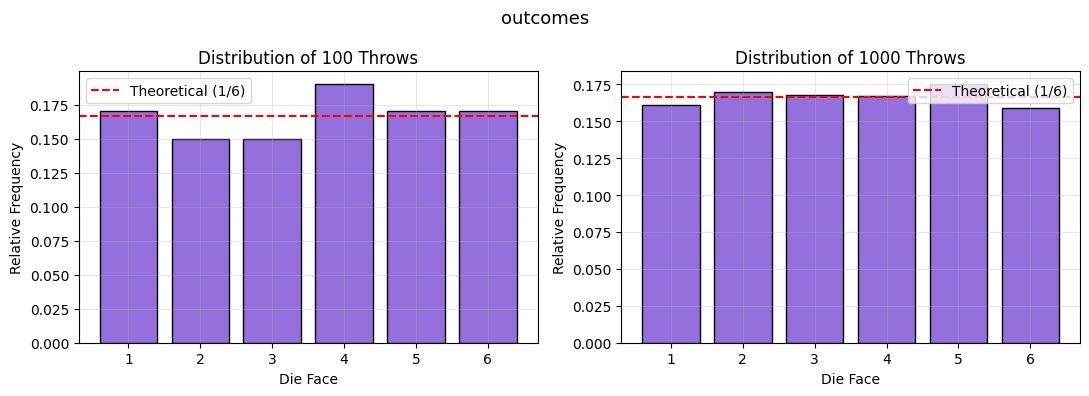

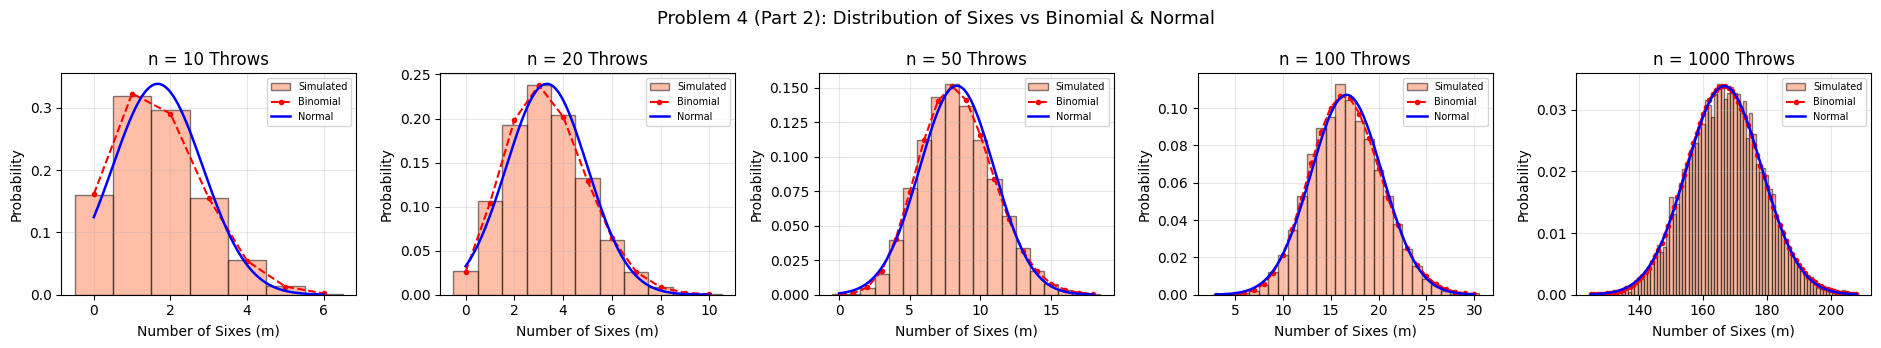

In [ ]:
# 4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, n_throws in zip([ax1, ax2], [100, 1000]):
    throws = np.random.randint(1, 7, size=n_throws)
    ax.hist(throws, bins=np.arange(0.5, 7.5, 1), density=True, color='mediumpurple', edgecolor='black', rwidth=0.8)
    ax.axhline(1/6, color='red', linestyle='--', lw=1.5, label='Theoretical (1/6)')
    ax.set_title(f"Distribution of {n_throws} Throws")
    ax.set_xlabel("Die Face")
    ax.set_ylabel("Relative Frequency")
    ax.set_xticks(range(1, 7))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("outcomes", fontsize=13)
plt.tight_layout()
plt.show()

# distrin of m sixes and  trials 
p_six = 1.0 / 6.0
n_values = [10, 20, 50, 100, 1000]
num_experiments = 10000

fig, axes = plt.subplots(1, len(n_values), figsize=(3.8 * len(n_values), 3.5))

for ax, n in zip(axes, n_values):
    # Simulate number of sixes obtained across 10,000 experiments of n throws
    sixes_counts = np.random.binomial(n=n, p=p_six, size=num_experiments)

    mu = n * p_six
    sigma = np.sqrt(n * p_six * (1 - p_six))

    k_min = max(0, int(mu - 3.5 * sigma))
    k_max = int(min(n, mu + 3.5 * sigma) + 1)
    m_range = np.arange(k_min, k_max + 1)

    # Plot simulated distribution
    bins = np.arange(k_min - 0.5, k_max + 1.5, 1)
    ax.hist(sixes_counts, bins=bins, density=True, alpha=0.5, color='coral', edgecolor='black', label='Simulated')

    # binomial PMF
    ax.plot(m_range, binom.pmf(m_range, n, p_six), 'ro--', markersize=3, label='Binomial')


    x_dense = np.linspace(k_min, k_max, 200)
    ax.plot(x_dense, norm.pdf(x_dense, loc=mu, scale=sigma), 'b-', lw=1.8, label='Normal')

    ax.set_title(f"n = {n}throws")
    ax.set_xlabel("Number of 6s")
    ax.set_ylabel("proby")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Problem 4 (Part 2): Distribution of Sixes vs Binomial & Normal", fontsize=13)
plt.tight_layout()
plt.show()